
# Used Car Price Analysis
### _Understanding used car pricing_

**Author**: Jhaden Goy
**ID**: 100916409 
**Date**: November 25, 2024

## 1. Introduction

The automotive market has always been a dynamic field, influenced by a variety of factors that significantly affect the pricing of vehicles. For this assignment, I chose to analyze a dataset on used car sales in India, which includes attributes such as brand, mileage, fuel type, transmission, number of owners, and asking price. The reason for selecting this topic stems from my long-standing interest in the car market. I find it fascinating to explore how different factors, such as a car's age, brand reputation, or fuel efficiency, contribute to its valuation in the market. This is the question I hope to answer in this assignment. I will specifically be exploring how all these different factors affect price and try to provide insight on why vehicles are priced the way they are. 


![Car Lot Photo](https://media.istockphoto.com/id/480652712/photo/dealer-new-cars-stock.jpg?s=612x612&w=0&k=20&c=Mzfb5oEeovQblEo160df-xFxfd6dGoLBkqjjDWQbd5E=)
##### *Image source: https://www.istockphoto.com/photos/new-car*



# 2. Methods

### 2.1 Data Collection 

This dataset contains information about used cars in the Indian market, comprising 9,582 entries with 11 detailed attributes. The data appears to be collected up to November 2024, providing a comprehensive view of the second-hand car market in India. Obtained from [Kaggle](https://www.kaggle.com/datasets/mohitkumar282/used-car-dataset/data) [1].

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
# Load data
file_path = "used_car_dataset.csv"
data = pd.read_csv(file_path)

### 2.2 Cleaning Data

The used car dataset contained non-numeric characters in the kmDriven and AskPrice columns (commas, "km", '₹'). These characters were removed using the str.replace method. There were also 47 missing values in the kmDriven column that were cleaned. These columns were then changed to float type to be fully ready for analysis. 

In [110]:
# Cleaning 'kmDriven' and 'AskPrice' columns
data['kmDriven'] = data['kmDriven'].str.replace(',', '').str.replace(' km', '').astype(float)
data['AskPrice'] = data['AskPrice'].str.replace('₹ ', '').str.replace(',', '').astype(float)

# Dropping all rows with missing values
data = data.dropna(axis=0)

# Display first 5 rows to check data
data.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,98000.0,Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...",195000.0
1,Toyota,Innova,2009,15,190000.0,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000.0
2,Volkswagen,VentoTest,2010,14,77246.0,Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999.0
3,Maruti Suzuki,Swift,2017,7,83500.0,Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,565000.0
4,Maruti Suzuki,Baleno,2019,5,45000.0,Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000.0


# 3. Analyses

### 3.1 Distributions

The distributions of the dataset will now be explored. I will be exploring: 
1. Brand
2. Age
3. Mileage
4. Transmission
6. Fuel Type
7. Asking Price

### 

### Brands

Starting with brand, it can be observed in this count plot that the top 10 brands in the dataset are: Maruti Suzuki, Hyundai, Honda, Toyota, Mahindra, Mercedes-Benz, Tata, BMW, Volkswagen and Audi. The brand that appeared the most in this set was Maruti Suzuki, followed by Hyundai and Honda. There were 5 brands that all tied for the least amount of appearances in the dataset (once) which were: Aston Martin, ICML, Ashok, Bentley and Maserati.

C:\Users\jhade\AppData\Local\Temp\ipykernel_4472\2001038105.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Brand", data= data, order= data['Brand'].value_counts().index[:10], palette="Set1")


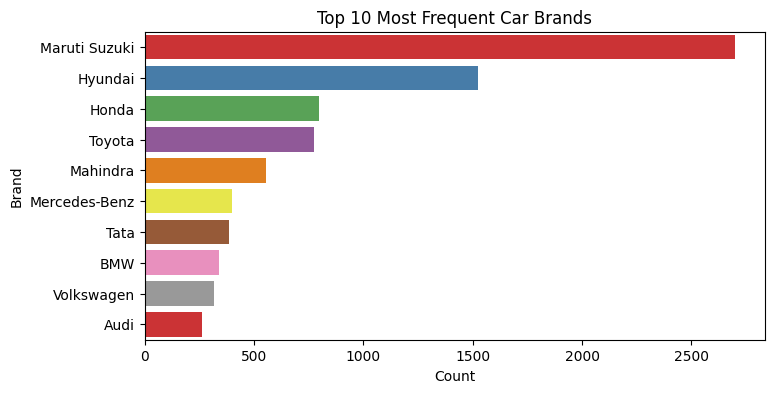

There are 38 unique brands in the dataset.
The brands are: ['Maruti Suzuki' (2699), 'Hyundai' (1523), 'Honda' (799), 'Toyota' (773), 'Mahindra' (557), 'Mercedes-Benz' (402), 'Tata' (384), 'BMW' (342), 'Volkswagen' (317), 'Audi' (264), 'Ford' (245), 'Renault' (239), 'Skoda' (182), 'Kia' (161), 'Chevrolet' (89), 'MG' (80), 'Nissan' (75), 'Jeep' (74), 'Land Rover' (71), 'Volvo' (48), 'Mini' (41), 'Jaguar' (34), 'Porsche' (24), 'Fiat' (22), 'Datsun' (22), 'Lexus' (20), 'Mitsubishi' (18), 'Isuzu' (10), 'Force' (6), 'Ambassador' (2), 'Ssangyong' (2), 'Rolls-Royce' (2), 'Bajaj' (2), 'Opel' (2), 'Aston Martin' (1), 'Ashok' (1), 'Bentley' (1), 'Maserati' (1)]


In [111]:
plt.figure(figsize=(8, 4))
sns.countplot(y="Brand", data= data, order= data['Brand'].value_counts().index[:10], palette="Set1")
plt.title("Top 10 Most Frequent Car Brands")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()

# Count unique brands
num_brands = data['Brand'].nunique()

# Display the number of unique brands
print(f"There are {num_brands} unique brands in the dataset.")

# Get value counts of brands
brand_counts = data['Brand'].value_counts()

# Format each brand with its count
formatted_brands = [f"'{brand}' ({count})" for brand, count in brand_counts.items()]
formatted_string = "The brands are: [" + ', '.join(formatted_brands) + "]"
print(formatted_string)


### Age

Here is a histogram of the age distribution of the cars in the dataset, with an added density curve to make the trend easier to follow. The data is skewed to the right, where most cars are under 10 years old. The average age of a car in this dataset is 7.6 years.

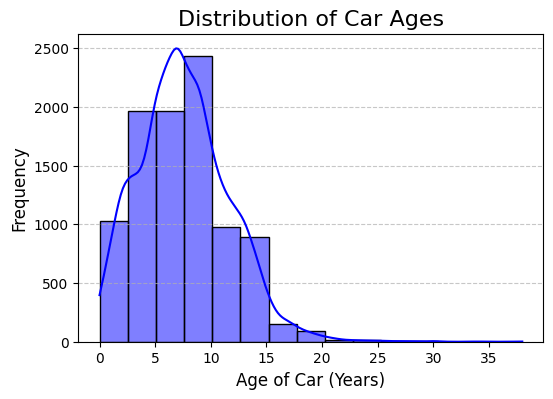

The average age of the cars in the dataset is 7.6 years.


In [112]:
plt.figure(figsize=(6, 4))
sns.histplot(data=data, x='Age', bins=15, kde=True, color='blue')
plt.title('Distribution of Car Ages', fontsize=16)
plt.xlabel('Age of Car (Years)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate the average age
average_age = data['Age'].mean()
print(f"The average age of the cars in the dataset is {average_age:.1f} years.")

### Mileage

Here is a histogram of the distribution of car mileage in the dataset, with an added density curve to make the trend easier to follow. Data is skewed to the right, with majority of cars' mileage being under 150,000km. The average mileage of the cars is 70605.9 km.

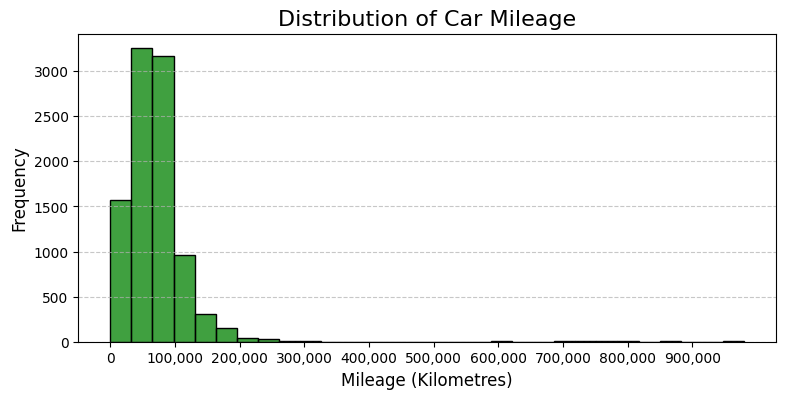

The average mileage of the cars in the dataset is 70605.9 km.


In [113]:
plt.figure(figsize=(9, 4))
sns.histplot(data=data, x='kmDriven', bins=30, kde=False, color='green')
plt.title('Distribution of Car Mileage', fontsize=16)
plt.xlabel('Mileage (Kilometres)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Explicitly format the x-axis ticks to show mileage in whole numbers
plt.xticks(
    ticks=range(0, int(data['kmDriven'].max()) + 1, 100000), 
    labels=[f"{x:,}" for x in range(0, int(data['kmDriven'].max()) + 1, 100000)]
)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate the average mileage
average_miles = data['kmDriven'].mean()
print(f"The average mileage of the cars in the dataset is {average_miles:.1f} km.")


### Transmission
Here in this count plot, the distribution of transmission types can be observed, being a very close 50/50 split between the number of automatic and manual transmissions in the dataset. 

C:\Users\jhade\AppData\Local\Temp\ipykernel_4472\3115724307.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data.Transmission, palette='viridis')


<Axes: title={'center': 'Distribution of Transmission Types'}, xlabel='count', ylabel='Transmission'>

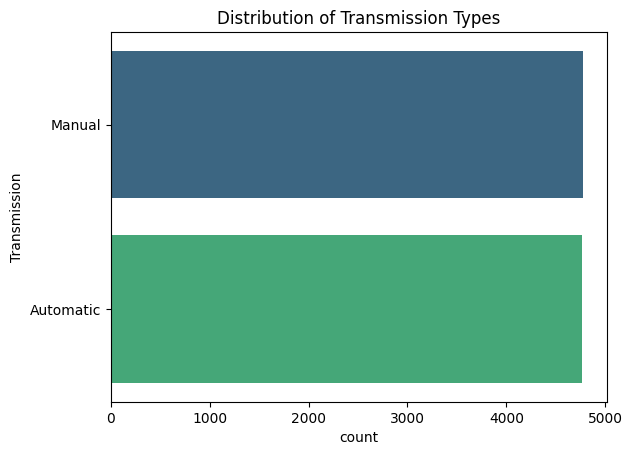

In [114]:
plt.title("Distribution of Transmission Types")
sns.countplot(data.Transmission, palette='viridis')

### Fuel Type

Here is a count plot for the distribution of fuel types of the cars in the dataset. Petrol and diesel cars are nearly the same, with hybrids being a little bit more rare among the dataset.

C:\Users\jhade\AppData\Local\Temp\ipykernel_4472\1564558716.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data.FuelType, palette='Set2')


<Axes: title={'center': 'Distribution of Fuel Types'}, xlabel='count', ylabel='FuelType'>

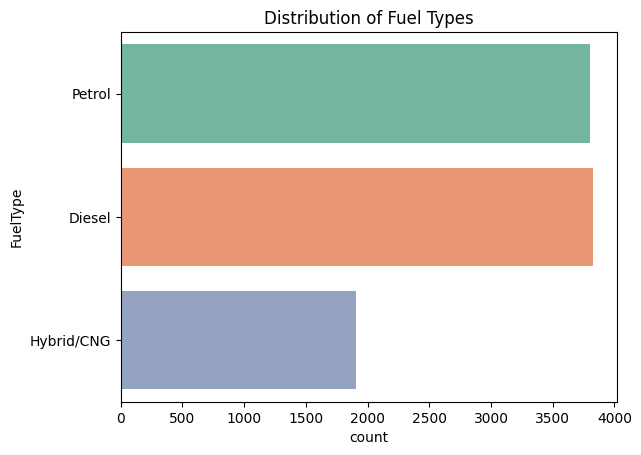

In [115]:
plt.title("Distribution of Fuel Types")
sns.countplot(data.FuelType, palette='Set2')

### Asking Price

Here is a histogram displaying the distribution of asking prices for each car in the dataset, with an added density curve to make it easier to follow the trend. Data is heavily skewed to the right, with most cars being well under ₹5,000,000. The average price of each car in the dataset is  ₹1,067,161.5.

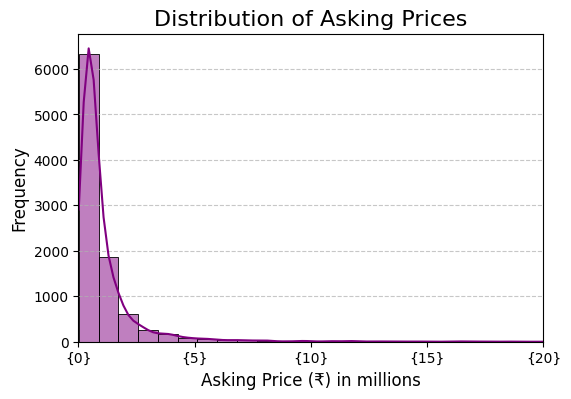

The average asking price of the cars in the dataset is ₹1067161.5


In [116]:
plt.figure(figsize=(6, 4))
sns.histplot(data=data, x='AskPrice', bins=50, kde=True, color='purple') 
plt.title('Distribution of Asking Prices', fontsize=16)
plt.xlabel('Asking Price (₹) in millions', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Properly formatting x-axis intervals
plt.xlim(0, 20000000)
plt.xticks(ticks=range(0, 20000001, 5000000), labels=[{x // 1000000} for x in range(0, 20000001, 5000000)])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate the average price
average_price = data['AskPrice'].mean()
print(f"The average asking price of the cars in the dataset is ₹{average_price:.1f}")


### 3.2 Some Relationships

1. Average asking price by transmission
2. Average asking price by fuel type
3. Kilometers driven and asking price
4. Age and asking price by brand

### Average Asking Price by Transmission
Examining price and transmission reveals that the average price of a used car with an automatic tranmission is much greater than a used car with a manual transmission, in general. 


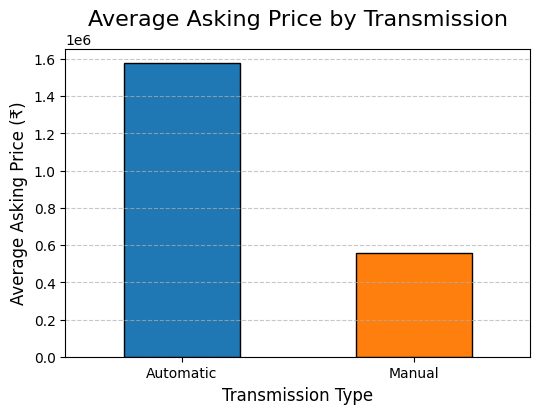

Transmission
Automatic    ₹1,576,289.90 
Manual         ₹559,419.40 
Name: AskPrice, dtype: object


In [117]:
plt.figure(figsize=(6, 4))
avg_price_by_transmission = data.groupby('Transmission')['AskPrice'].mean()
avg_price_by_transmission.plot(kind='bar', color=['#1f77b4', '#ff7f0e'], edgecolor='black')
plt.title('Average Asking Price by Transmission', fontsize=16)
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Average Asking Price (₹)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate the average asking price for automatic and manual transmissions
avg_price_transmission = data.groupby('Transmission')['AskPrice'].mean()

# Format the output with commas 
formatted_prices = avg_price_transmission.apply(lambda x: f"₹{x:,.2f} ")

# Display results
print(formatted_prices)




### Average Asking Price by Fuel Type
Examining asking price and fuel type reveals that diesel fueled vehicles are the most expensive, followed by petrol fueled vehicles and lastly hybirds. 

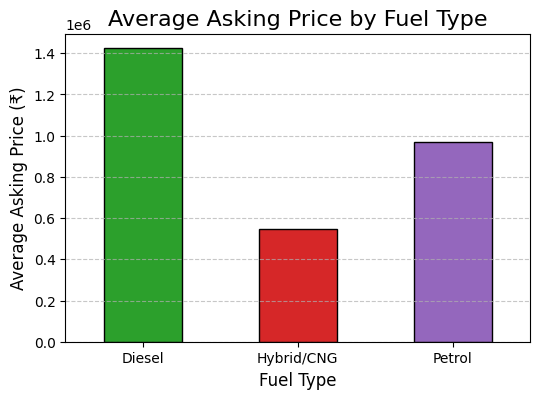

FuelType
Diesel        ₹1,423,465.96 
Hybrid/CNG      ₹548,593.23 
Petrol          ₹968,250.04 
Name: AskPrice, dtype: object


In [118]:
plt.figure(figsize=(6, 4))
avg_price_by_fuel_type = data.groupby('FuelType')['AskPrice'].mean()
avg_price_by_fuel_type.plot(kind='bar', color=['#2ca02c', '#d62728', '#9467bd', '#8c564b'], edgecolor='black')
plt.title('Average Asking Price by Fuel Type', fontsize=16)
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Average Asking Price (₹)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate the average asking price by fuel type
avg_price_by_fuel_type = data.groupby('FuelType')['AskPrice'].mean()

# Format the output with commas 
formatted_prices = avg_price_by_fuel_type.apply(lambda x: f"₹{x:,.2f} ")

# Display results
print(formatted_prices)


### Kilometers Driven vs Asking Price (by Selected Brands)
Since there are 39 brands within the dataset, I've sampled a mix of luxury, middle-class and economy brands in order to not over-crowd the data visualizations. However, it is clear that when examining kilometers driven and asking price, the clear trend is that vehicle prices drop as the mileage increases.

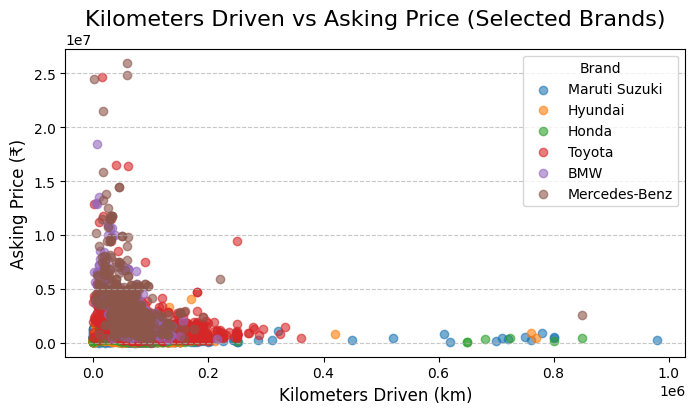

In [119]:
# Select brands
selected_brands = ['Maruti Suzuki', 'Hyundai', 'Honda', 'Toyota', 'BMW', 'Mercedes-Benz']
filtered_data = data[data['Brand'].isin(selected_brands)]

# Filter data by brand
plt.figure(figsize=(8, 4))
for brand in selected_brands:
    brand_data = filtered_data[filtered_data['Brand'] == brand]
    plt.scatter(brand_data['kmDriven'], brand_data['AskPrice'], label=brand, alpha=0.6)

# Plot data
plt.title('Kilometers Driven vs Asking Price (Selected Brands)', fontsize=16)
plt.xlabel('Kilometers Driven (km)', fontsize=12)
plt.ylabel('Asking Price (₹)', fontsize=12)
plt.legend(title='Brand', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Average Asking Price vs Age (by Selected Brands)

Using the same set of selected brands as the previous relationship analyzed, we can determine that luxury brands maintain higher prices even as cars age, with a slower decline compared to economy brands. Brands such as BMW and Mercedes show a notable price premium across all age groups, while brands like Maruti Suzuki exhibit steep declines as cars age.

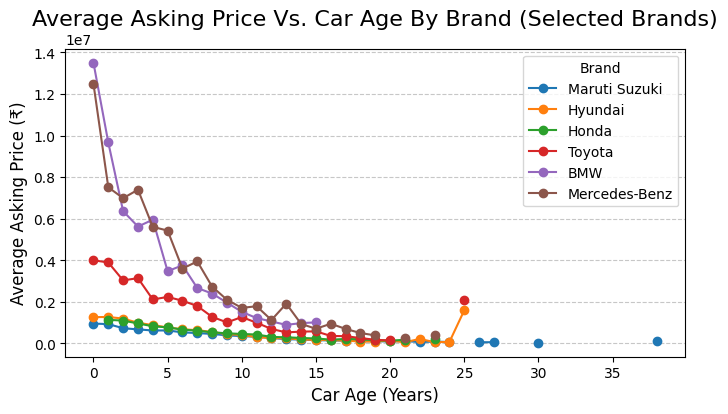

In [120]:
# Selected brands
selected_brands = ['Maruti Suzuki', 'Hyundai', 'Honda', 'Toyota', 'BMW', 'Mercedes-Benz']

# Calculate the average asking price by age and brand for selected brands
avg_price_by_age_selected = data.groupby(['Brand', 'Age'])['AskPrice'].mean().unstack()

# Filter data by brand
avg_price_by_age_selected = avg_price_by_age_selected.loc[selected_brands]

# Plot data
plt.figure(figsize=(8, 4))
for brand in avg_price_by_age_selected.index:
    plt.plot(avg_price_by_age_selected.columns, avg_price_by_age_selected.loc[brand], label=brand, marker='o')

plt.title('Average Asking Price Vs. Car Age By Brand (Selected Brands)', fontsize=16)
plt.xlabel('Car Age (Years)', fontsize=12)
plt.ylabel('Average Asking Price (₹)', fontsize=12)
plt.legend(title='Brand', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# 4. Discussion

In this assignment, data from the used car market in India was analyzed to explore how various factors, such as brand, age, mileage, transmission type, and fuel type, influence vehicle prices. The findings reveal distinct patterns and relationships between these factors and asking prices.

One key observation is that cars with automatic transmissions are significantly more expensive than their manual counterparts. This difference can be attributed to the overwhelming popularity of automatic vehicles and the fact that manual cars are typically older, further lowering their value due to age-related depreciation. This also highlights the impact of age on price, which varies notably across brands. After exploring the effect of age on price with a selected group of brands it was found that luxury brands, such as BMW and Mercedes-Benz, retain their value longer, whereas economy brands like Maruti Suzuki and Hyundai experience steeper declines in price as they age. This underlines the importance of brand reputation and perceived quality in the used car market.

The influence of fuel type on price was also examined, with diesel-powered vehicles being the most expensive, followed by petrol and hybrid vehicles. This trend reflects the specialized nature of diesel vehicles, which are often designed for towing, heavy loads, or off-roading. Their superior durability, higher torque, and fuel efficiency justify their higher manufacturing costs, which are reflected in their market prices.

Lastly, mileage was found to inversely correlate with price; vehicles with higher mileage command lower asking prices. This relationship is intuitive, as higher mileage suggests greater wear and tear, increasing the likelihood of mechanical issues and the need for repairs. This insight reinforces the idea that vehicle condition, alongside other factors, is critical in determining its value.

# 5. References

1. Source data - https://www.kaggle.com/datasets/mohitkumar282/used-car-dataset/data
2. Pandas for data manipulation.
3. Seaborn for data visualization.
4. Matplotlib for data visualization. 